In [2]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

os.makedirs("../figures/eda", exist_ok=True)

pd.set_option("display.max_columns", 100)

### Downloading Price dataset

In [50]:
### We are downloading data for the given period between start_date and end_date

def get_price_data(start_date, end_date, source_url):
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)
    
    date_ranges = []
    
    current = start_date
    
    while current <= end_date:
        week_end = current + timedelta(days=6)
        if week_end > end_date:
            week_end = end_date
        date_ranges.append((current, week_end))
        current = week_end + timedelta(days=1)
        
    all_price_data = []
    
    url = source_url
    
    for start, end in date_ranges:
        params = {
            "from": start.strftime("%Y-%m-%d"),
            "to": end.strftime("%Y-%m-%d"),
            "format": "json"
        }
        try:
            r = requests.get(url, params=params)
            r.raise_for_status()
            data = r.json()
            if "data" in data:
                df = pd.json_normalize(data["data"]) #Normalize semi-structured JSON data into a flat table
                all_price_data.append(df)
        except Exception as e:
            print(f"Error for {start} to {end}: {e}")
        # print(f"Download complete...")
    price_df = pd.concat(all_price_data, ignore_index=True)
    return price_df

price_df = get_price_data("2023-01-01", "2024-12-31", source_url="https://data.elexon.co.uk/bmrs/api/v1/balancing/pricing/market-index")
price_df.head(10)

,startTime,dataProvider,settlementDate,settlementPeriod,price,volume
0,2023-01-07T00:00:00Z,APXMIDP,2023-01-07,1,3.22,853.05
1,2023-01-07T00:00:00Z,N2EXMIDP,2023-01-07,1,0.00,0.00
2,2023-01-06T23:30:00Z,APXMIDP,2023-01-06,48,20.32,789.90
3,2023-01-06T23:30:00Z,N2EXMIDP,2023-01-06,48,0.00,0.00
4,2023-01-06T23:00:00Z,APXMIDP,2023-01-06,47,71.31,1048.30
5,2023-01-06T23:00:00Z,N2EXMIDP,2023-01-06,47,0.00,0.00
6,2023-01-06T22:30:00Z,APXMIDP,2023-01-06,46,72.92,1698.70
7,2023-01-06T22:30:00Z,N2EXMIDP,2023-01-06,46,0.00,0.00
8,2023-01-06T22:00:00Z,APXMIDP,2023-01-06,45,83.47,1765.10
9,2023-01-06T22:00:00Z,N2EXMIDP,2023-01-06,45,0.00,0.00


In [51]:
timestamp_col = "settlementDate"
price_col = "price"
price_df[timestamp_col] = pd.to_datetime(price_df[timestamp_col])
price_df = price_df.sort_values(timestamp_col).reset_index(drop=True)
print("Shape:", price_df.shape)

Shape: (60219, 6)


In [52]:
print(price_df["price"].describe())

count    60219.000000
mean        41.869590
std         49.515067
min        -77.290000
25%          0.000000
50%          0.000000
75%         81.950000
max        605.170000
Name: price, dtype: float64


In [54]:
zero_prices = (price_df["price"] == 0).sum()

print(f"Zero-price observations: {zero_prices}")
print(f"Percentage: {zero_prices/len(price_df)*100:.2f}%")

Zero-price observations: 30017
Percentage: 49.85%


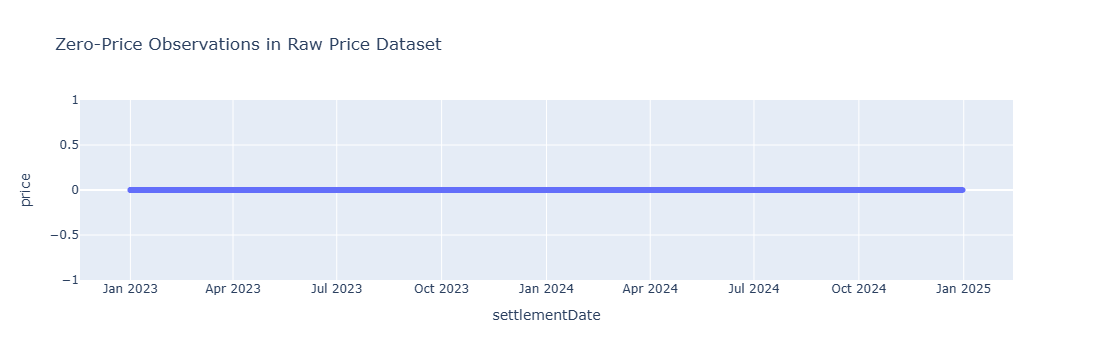

In [55]:
zeros = price_df[price_df["price"] == 0]

fig = px.scatter(
    zeros,
    x=timestamp_col,
    y="price",
    title="Zero-Price Observations in Raw Price Dataset"
)

fig.show()

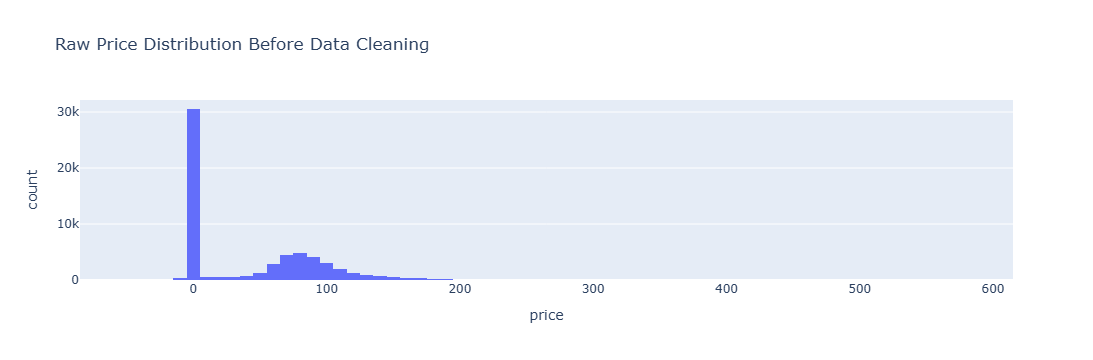

In [40]:
fig = px.histogram(
    price_df,
    x="price",
    nbins=100,
    title="Raw Price Distribution Before Data Cleaning"
)

fig.show()

### Data Quality Assessment

Initial inspection of the raw N2EX MIDP dataset revealed a number of observations where the reported market price was exactly £0/MWh.

These values do not represent genuine market-clearing prices but correspond to missing or invalid records within the source dataset. Including them would artificially distort the price distribution and bias summary statistics, resulting in:

Underestimation of the average electricity price
An unrealistic concentration of observations at zero
Potential degradation of model performance

Consequently, zero-price observations were removed prior to feature engineering and model training.

In [46]:
clean_price_df =  price_df[price_df['dataProvider'] == 'APXMIDP'].copy()

In [56]:
clean_price_df.shape

(30149, 14)

In [59]:
raw_stats = pd.DataFrame({
    "Dataset": ["price_df","clean_price_df"],
    "Mean Price":[
        price_df["price"].mean(),
        clean_price_df["price"].mean()
    ],
    "Median Price":[
        price_df["price"].median(),
        clean_price_df["price"].median()
    ],
    "Max Price":[
        price_df["price"].max(),
        clean_price_df["price"].max()
    ],
    "Min Price":[
        price_df["price"].min(),
        clean_price_df["price"].min()
    ],
    "Zero values":[
        (price_df["price"] == 0).sum(),
        (clean_price_df["price"] == 0).sum()
    ]
})

In [60]:
raw_stats

,Dataset,Mean Price,Median Price,Max Price,Min Price,Zero values
0,price_df,41.869590,0.00,605.17,-77.29,30017
1,clean_price_df,83.443669,81.84,605.17,-77.29,10


In [26]:
# Dataset overview
print("Date range:", price_df[timestamp_col].min(), "to", price_df[timestamp_col].max())
print("Number of days:", price_df[timestamp_col].dt.date.nunique())
print("Number of rows:", len(price_df))

overview = pd.DataFrame({
    "column": price_df.columns,
    "dtype": price_df.dtypes.astype(str).values,
    "missing_values": price_df.isna().sum().values,
    "missing_percent": (price_df.isna().mean() * 100).round(2).values,
    "unique_values": price_df.nunique().values
})

print(f"Price mean : £{price_df['price'].mean():.1f}/MWh")
print(f"Price range: £{price_df['price'].min():.1f} to £{price_df['price'].max():.1f}")

Shape: (60219, 6)
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
Number of days: 731
Number of rows: 60219
Price mean : £41.9/MWh
Price range: £-77.3 to £605.2


In [61]:
# Adding time based features

clean_price_df["date"] = price_df[timestamp_col].dt.date
clean_price_df["hour"] = price_df[timestamp_col].dt.hour
clean_price_df["minute"] = price_df[timestamp_col].dt.minute
clean_price_df["day_of_week"] = price_df[timestamp_col].dt.dayofweek
clean_price_df["day_name"] = price_df[timestamp_col].dt.day_name()
clean_price_df["month"] = price_df[timestamp_col].dt.month
clean_price_df["month_name"] = price_df[timestamp_col].dt.month_name()

# GB has 48 half-hourly settlement periods per day
clean_price_df["settlement_period"] = (
    clean_price_df[timestamp_col].dt.hour * 2
    + (clean_price_df[timestamp_col].dt.minute // 30)
    + 1
)

clean_price_df[[timestamp_col, price_col, "settlement_period", "hour", "day_name", "month_name"]].head()

,settlementDate,price,settlement_period,hour,day_name,month_name
1,2023-01-01,220.55,1,0,Sunday,January
3,2023-01-01,219.76,1,0,Sunday,January
5,2023-01-01,213.65,1,0,Sunday,January
7,2023-01-01,201.56,1,0,Sunday,January
9,2023-01-01,183.28,1,0,Sunday,January


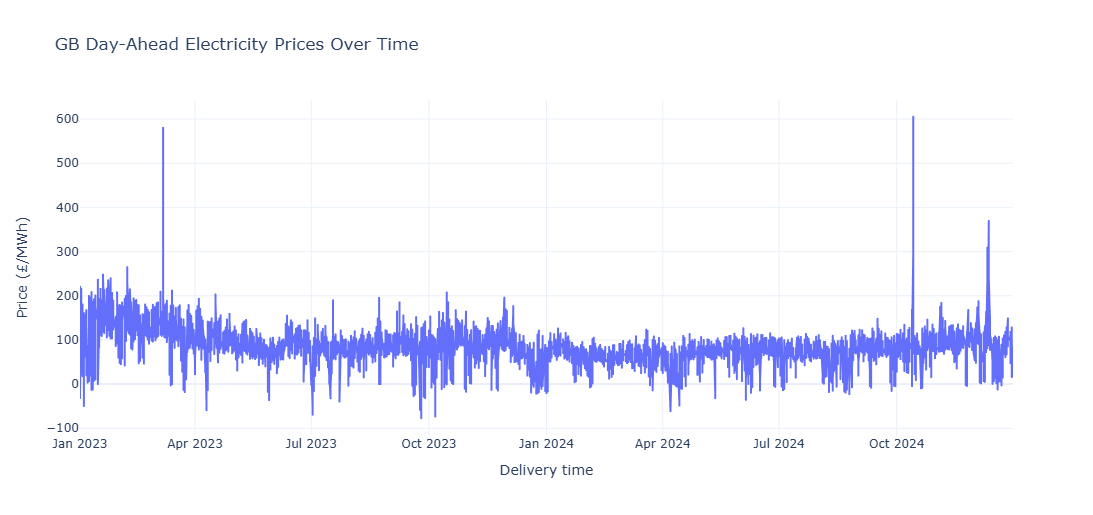

In [62]:
fig = px.line(
    clean_price_df,
    x=timestamp_col,
    y=price_col,
    title="GB Day-Ahead Electricity Prices Over Time",
    labels={
        timestamp_col: "Delivery time",
        price_col: "Price (£/MWh)"
    }
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=500,
    hovermode="x unified"
)

fig.show()

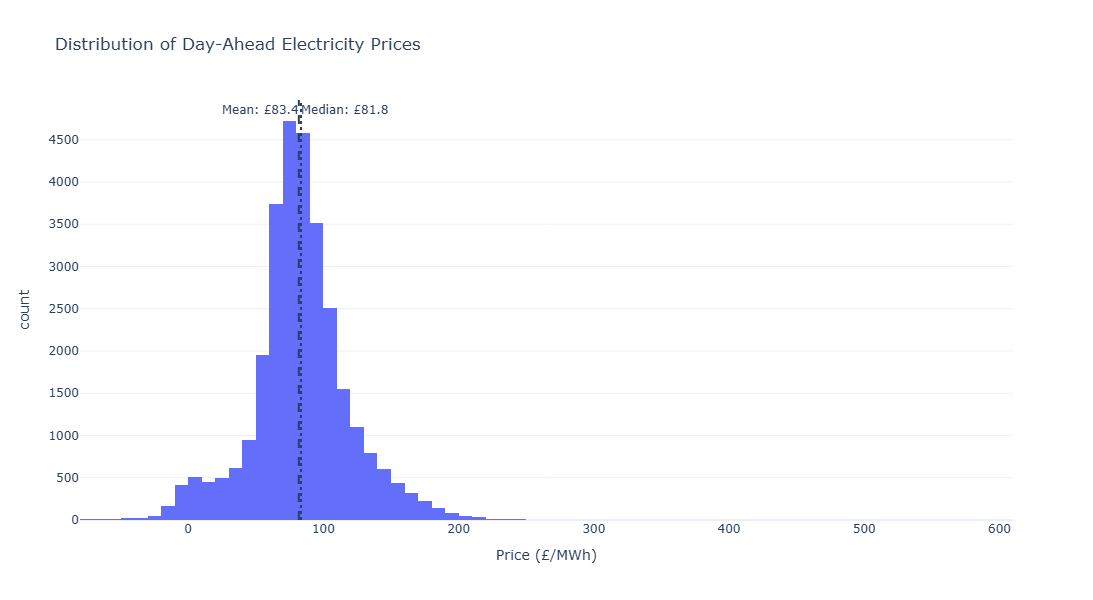

In [65]:
fig = px.histogram(
    clean_price_df,
    x=price_col,
    nbins=100,
    title="Distribution of Day-Ahead Electricity Prices",
    labels={
        price_col: "Price (£/MWh)",
        "count": "Number of settlement periods"
    }
)

fig.add_vline(
    x=clean_price_df[price_col].median(),
    line_dash="dash",
    annotation_text=f"Median: £{clean_price_df[price_col].median():.1f}",
    annotation_position="top right"
)

fig.add_vline(
    x=clean_price_df[price_col].mean(),
    line_dash="dot",
    annotation_text=f"Mean: £{clean_price_df[price_col].mean():.1f}",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=600
)

fig.show()